In [34]:
# ignore
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


In [30]:
df = pd.read_csv("../../data/out.csv", index_col=0, sep=";")
df.head()

,CN.VIEWS3600,CN.VIEWS7200,CN.VIEWS10800,CN.VIEWS14400,CN.VIEWS18000,CN.VIEWS21600,CN.VIEWS25200,CN.VIEWS28800,CN.VIEWS32400,CN.VIEWS36000,...,CN.VIEWS57600,CN.VIEWS61200,CN.VIEWS64800,CN.VIEWS68400,CN.VIEWS72000,CN.VIEWS75600,CN.VIEWS79200,CN.VIEWS82800,CN.VIEWS86400,CN.VIEWS604800
timestamp,,,,,,,,,,,,,,,,,,,,,
1532558814,3.521326e+05,4.597264e+05,6.200204e+05,8.535335e+05,1.112266e+06,1.254825e+06,1.454170e+06,1.605570e+06,1.744270e+06,1.842567e+06,...,2.485198e+06,2.543591e+06,2.637730e+06,2.730520e+06,2.814682e+06,2.908785e+06,2.971709e+06,3.076668e+06,3.180984e+06,7.743659e+06
1746896415,2.047341e+06,3.770382e+06,5.534765e+06,7.725375e+06,9.677998e+06,1.135324e+07,1.296534e+07,1.442794e+07,1.545016e+07,1.644728e+07,...,2.342231e+07,2.461670e+07,2.579357e+07,2.685656e+07,2.788640e+07,2.895555e+07,2.989416e+07,3.073228e+07,3.146432e+07,6.469111e+07
1639866937,2.904805e+06,4.246268e+06,5.618159e+06,6.838388e+06,7.948328e+06,9.075992e+06,1.018191e+07,1.127606e+07,1.223815e+07,1.318694e+07,...,1.825227e+07,1.887863e+07,1.937952e+07,1.996549e+07,2.057697e+07,2.115987e+07,2.170075e+07,2.219089e+07,2.265056e+07,3.685009e+07
1732989619,3.408049e+06,6.448769e+06,9.814262e+06,1.372104e+07,1.714361e+07,2.039948e+07,2.330253e+07,2.580370e+07,2.820106e+07,3.031051e+07,...,3.913266e+07,4.064038e+07,4.198561e+07,4.320256e+07,4.438142e+07,4.546235e+07,4.648452e+07,4.752224e+07,4.860935e+07,1.284348e+08
1670105055,1.596129e+06,2.668068e+06,3.730841e+06,4.962771e+06,6.047904e+06,6.990349e+06,7.965495e+06,8.999206e+06,9.999294e+06,1.089206e+07,...,1.613455e+07,1.692815e+07,1.779252e+07,1.858162e+07,1.934281e+07,2.004852e+07,2.069734e+07,2.187942e+07,2.278712e+07,5.810252e+07


In [31]:
target_col = "CN.VIEWS604800"

# Создаём производные колонки (темп роста между последовательными точками)
view_cols = [c for c in df.columns if "VIEWS" in c and c != target_col]

print(f"Original features: {len(view_cols)}")
print("Creating derivatives...")

for i in range(len(view_cols) - 1):
    col1 = view_cols[i]
    col2 = view_cols[i + 1]
    deriv_col = f"{col1}_DERIV"

    # Производная = темп роста между двумя последовательными точками
    df[deriv_col] = (df[col2] - df[col1]) / (
        df[col1] + 1
    )  # +1 чтобы избежать деления на 0

print(f"\nNew shape: {len(df)} rows × {len(df.columns)} columns")
print(f"Added {len(df.columns) - len(view_cols) - 1} derivative features")

# Показываем первые несколько новых колонок
derivative_cols = [c for c in df.columns if "DERIV" in c]
print(f"\nDerivative columns: {derivative_cols[:5]}...")
print("\nSample of derivative values:")
print(df[derivative_cols[:5]].head())

Original features: 24
Creating derivatives...

New shape: 257 rows × 48 columns
Added 23 derivative features

Derivative columns: ['CN.VIEWS3600_DERIV', 'CN.VIEWS7200_DERIV', 'CN.VIEWS10800_DERIV', 'CN.VIEWS14400_DERIV', 'CN.VIEWS18000_DERIV']...

Sample of derivative values:
            CN.VIEWS3600_DERIV  CN.VIEWS7200_DERIV  CN.VIEWS10800_DERIV  \
timestamp                                                                 
1532558814            0.305548            0.348672             0.376621   
1746896415            0.841599            0.467959             0.395791   
1639866937            0.461808            0.323082             0.217194   
1732989619            0.892217            0.521881             0.398071   
1670105055            0.671586            0.398330             0.330202   

            CN.VIEWS14400_DERIV  CN.VIEWS18000_DERIV  
timestamp                                             
1532558814             0.303131             0.128170  
1746896415             0.252754 


OUTLIER DETECTION

Detecting outliers using IQR method (3*IQR threshold)...
  CN.VIEWS3600: 4 outliers
  CN.VIEWS18000: 1 outliers
  CN.VIEWS21600: 2 outliers
  CN.VIEWS25200: 2 outliers
  CN.VIEWS28800: 2 outliers
  CN.VIEWS32400: 2 outliers
  CN.VIEWS36000: 2 outliers
  CN.VIEWS39600: 1 outliers
  CN.VIEWS43200: 1 outliers
  CN.VIEWS46800: 1 outliers
  CN.VIEWS50400: 1 outliers
  CN.VIEWS54000: 1 outliers
  CN.VIEWS57600: 1 outliers
  CN.VIEWS61200: 1 outliers
  CN.VIEWS64800: 1 outliers
  CN.VIEWS68400: 1 outliers
  CN.VIEWS3600_DERIV: 1 outliers
  CN.VIEWS7200_DERIV: 1 outliers
  CN.VIEWS10800_DERIV: 2 outliers
  CN.VIEWS14400_DERIV: 4 outliers
  CN.VIEWS18000_DERIV: 5 outliers
  CN.VIEWS21600_DERIV: 5 outliers
  CN.VIEWS25200_DERIV: 7 outliers
  CN.VIEWS28800_DERIV: 8 outliers
  CN.VIEWS32400_DERIV: 4 outliers
  CN.VIEWS36000_DERIV: 5 outliers
  CN.VIEWS39600_DERIV: 5 outliers
  CN.VIEWS43200_DERIV: 5 outliers
  CN.VIEWS46800_DERIV: 4 outliers
  CN.VIEWS50400_DERIV: 3 outliers
  

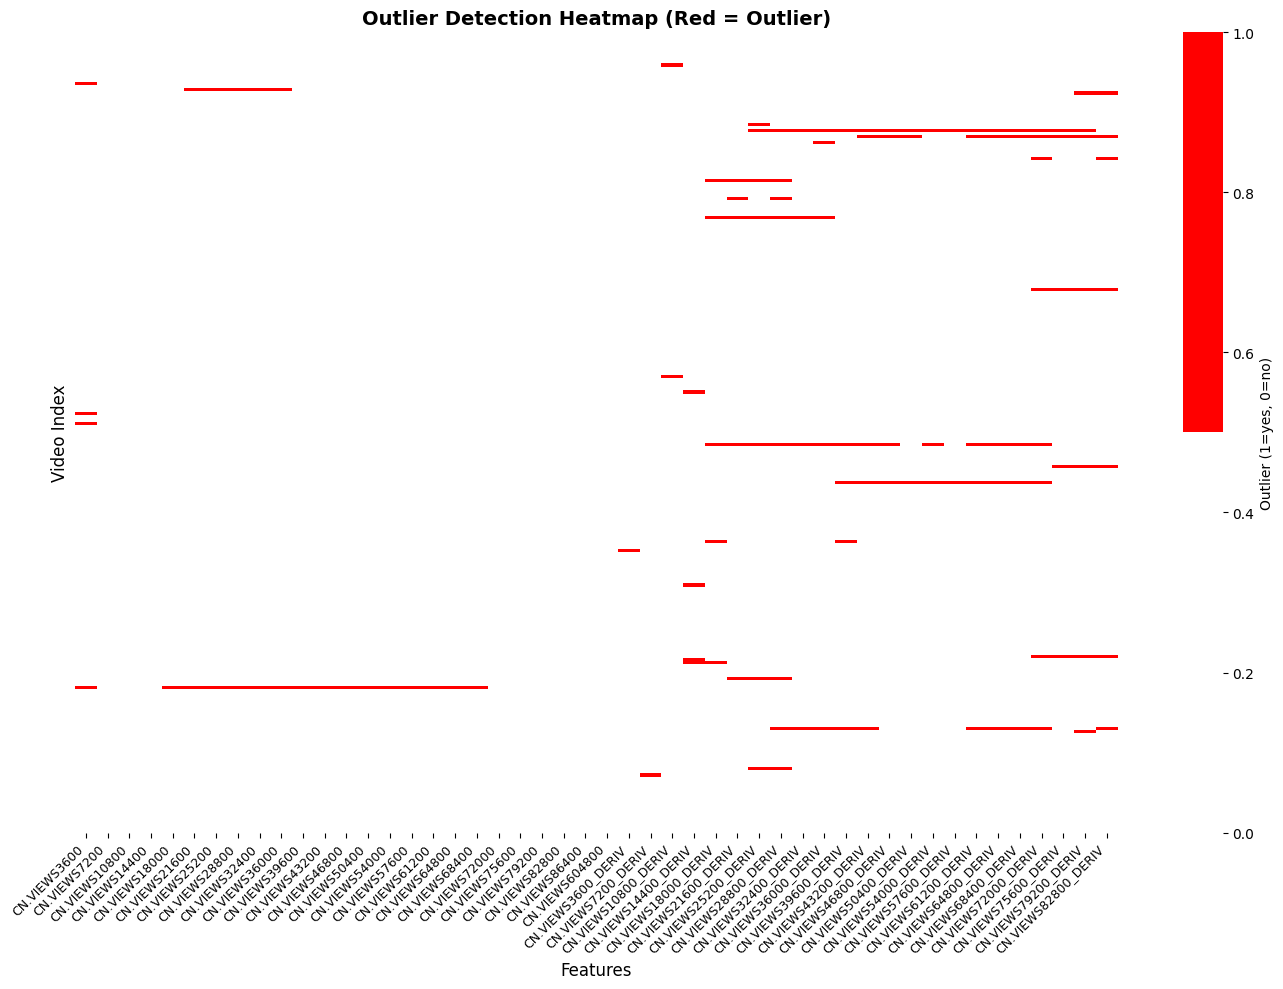

✓ Saved: outliers_heatmap.png

Z-score analysis for Target variable:
  Videos with Z-score > 3: 2
  Indices: [1720891980, 1750525208]

  Details of extreme outliers:
    Row 1720891980: CN.VIEWS604800 = 1.58e+08 (Z-score: 3.52)
    Row 1750525208: CN.VIEWS604800 = 1.41e+08 (Z-score: 3.01)


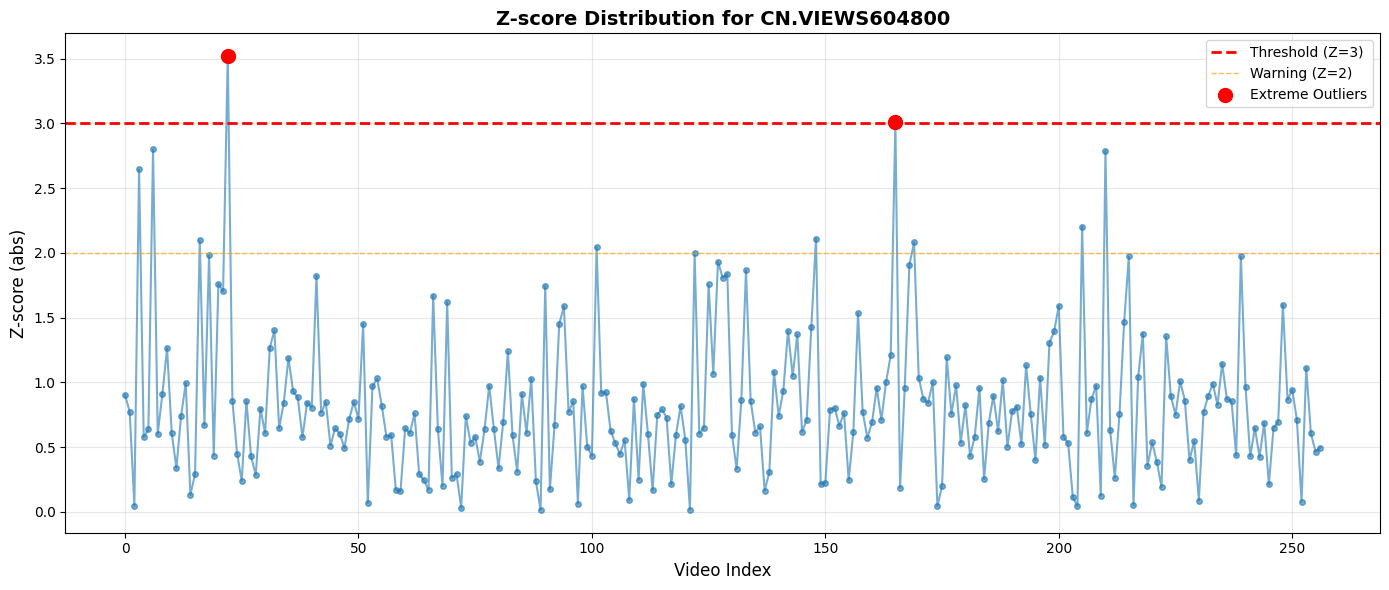

✓ Saved: outliers_zscore.png



In [32]:
# === OUTLIER DETECTION HEATMAP ===
print("\n" + "=" * 70)
print("OUTLIER DETECTION")
print("=" * 70)

# Выбираем только колонки с просмотрами (без производных)
# view_cols_for_outliers = [c for c in df.columns if "VIEWS" in c and "DERIV" not in c]
view_cols_for_outliers = df.columns

# Метод 1: IQR (InterQuartile Range)
print("\nDetecting outliers using IQR method (3*IQR threshold)...")
outlier_scores = pd.DataFrame(index=df.index, columns=view_cols_for_outliers)

outlier_count_total = 0
outlier_rows_set = set()

for col in view_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR

    # Отмечаем выбросы: 1 если выброс, 0 если нет
    is_outlier = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype(int)
    outlier_scores[col] = is_outlier

    outlier_count = is_outlier.sum()
    outlier_count_total += outlier_count
    if outlier_count > 0:
        # Получаем индексы выбросов
        outlier_indices = df.index[is_outlier.astype(bool)]
        outlier_rows_set.update(outlier_indices)
        print(f"  {col}: {outlier_count} outliers")

outlier_scores = outlier_scores.astype(int)
print(f"\nTotal outlier cells: {outlier_count_total}")
print(
    f"Rows with at least one outlier: {len(outlier_rows_set)} ({len(outlier_rows_set) / len(df) * 100:.2f}%)"
)

# Визуализация выбросов - heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    outlier_scores,
    cmap=["white", "red"],
    cbar_kws={"label": "Outlier (1=yes, 0=no)"},
    ax=ax,
    xticklabels=True,
    yticklabels=False,
)
ax.set_title(
    "Outlier Detection Heatmap (Red = Outlier)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Video Index", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("outliers_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: outliers_heatmap.png\n")

# Метод 2: Z-score для целевой переменной
print("Z-score analysis for Target variable:")

target_col = "CN.VIEWS604800"
z_scores = np.abs(stats.zscore(df[target_col]))
threshold_z = 3

extreme_outliers = df.index[z_scores > threshold_z].tolist()
print(f"  Videos with Z-score > 3: {len(extreme_outliers)}")

if len(extreme_outliers) > 0:
    print(f"  Indices: {extreme_outliers}")
    print("\n  Details of extreme outliers:")
    for idx in extreme_outliers:
        val = df.loc[idx, target_col]
        z = z_scores[list(df.index).index(idx)]
        print(f"    Row {idx}: {target_col} = {val:.2e} (Z-score: {z:.2f})")

# Визуализация Z-scores
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(df)), z_scores, marker="o", linestyle="-", markersize=4, alpha=0.6)
ax.axhline(y=3, color="r", linestyle="--", linewidth=2, label="Threshold (Z=3)")
ax.axhline(
    y=2, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="Warning (Z=2)"
)
extreme_indices = [list(df.index).index(idx) for idx in extreme_outliers]
if len(extreme_indices) > 0:
    ax.scatter(
        extreme_indices,
        z_scores[extreme_indices],
        color="red",
        s=100,
        zorder=5,
        label="Extreme Outliers",
    )
ax.set_xlabel("Video Index", fontsize=12)
ax.set_ylabel("Z-score (abs)", fontsize=12)
ax.set_title(f"Z-score Distribution for {target_col}", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outliers_zscore.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: outliers_zscore.png\n")

print("=" * 70)

In [35]:
# === REMOVE OUTLIERS ===
print("\n" + "=" * 70)
print("REMOVING OUTLIERS")
print("=" * 70)

print(f"\nDataset before cleaning: {len(df)} rows × {len(df.columns)} columns")

# Метод 1: Удаление с помощью IQR
print("\nRemoving outliers detected by IQR method...")
df_cleaned_iqr = df[~df.index.isin(outlier_rows_set)].copy()
removed_count_iqr = len(df) - len(df_cleaned_iqr)
print(f"  Removed {removed_count_iqr} rows ({removed_count_iqr / len(df) * 100:.2f}%)")
print(f"  Dataset after IQR cleaning: {len(df_cleaned_iqr)} rows")

# Метод 2: Удаление экстремальных выбросов по Z-score
print("\nRemoving extreme outliers detected by Z-score method...")
z_scores = np.abs(stats.zscore(df[target_col]))
extreme_outlier_mask = z_scores > 3
df_cleaned_zscore = df[~extreme_outlier_mask].copy()
removed_count_zscore = len(df) - len(df_cleaned_zscore)
print(
    f"  Removed {removed_count_zscore} rows ({removed_count_zscore / len(df) * 100:.2f}%)"
)
print(f"  Dataset after Z-score cleaning: {len(df_cleaned_zscore)} rows")

# Используем IQR метод по умолчанию (более консервативный)
df_final = df_cleaned_iqr.copy()
print("\n" + "-" * 70)
print("USING IQR METHOD FOR FINAL CLEANED DATASET (more conservative)")
print("-" * 70)
print(f"Final dataset: {len(df_final)} rows × {len(df_final.columns)} columns")
print(f"Total removed: {len(df) - len(df_final)} rows")

# Статистика по целевой переменной
print(f"\n{target_col} Statistics:")
print(
    f"  Before: mean={df[target_col].mean():.2e}, std={df[target_col].std():.2e}, min={df[target_col].min():.2e}, max={df[target_col].max():.2e}"
)
print(
    f"  After:  mean={df_final[target_col].mean():.2e}, std={df_final[target_col].std():.2e}, min={df_final[target_col].min():.2e}, max={df_final[target_col].max():.2e}"
)

# Сохраняем очищенный датасет
output_path = "../../data/out_cleaned.csv"
df_final.to_csv(output_path, sep=";")
print(f"\n✓ Saved cleaned dataset to: {output_path}")

# Удаляем исходный df и используем очищенный для дальнейших анализов
df = df_final
print("\n" + "=" * 70)



REMOVING OUTLIERS

Dataset before cleaning: 257 rows × 48 columns

Removing outliers detected by IQR method...
  Removed 32 rows (12.45%)
  Dataset after IQR cleaning: 225 rows

Removing extreme outliers detected by Z-score method...
  Removed 2 rows (0.78%)
  Dataset after Z-score cleaning: 255 rows

----------------------------------------------------------------------
USING IQR METHOD FOR FINAL CLEANED DATASET (more conservative)
----------------------------------------------------------------------
Final dataset: 225 rows × 48 columns
Total removed: 32 rows

CN.VIEWS604800 Statistics:
  Before: mean=3.85e+07, std=3.41e+07, min=2.75e+06, max=1.58e+08
  After:  mean=3.70e+07, std=3.31e+07, min=2.75e+06, max=1.58e+08

✓ Saved cleaned dataset to: ../../data/out_cleaned.csv



In [37]:
# === USING SANITIZERS (object-oriented approach) ===
import sys
sys.path.insert(0, "../../")

print("\n" + "=" * 70)
print("SANITIZERS: Object-Oriented Data Cleaning")
print("=" * 70)

# Reload original data for demonstration
df_original = pd.read_csv("../../data/out.csv", index_col=0, sep=";")
print(f"\nOriginal dataset: {len(df_original)} rows")

# Import sanitizers
from src.sanitizers import IQRSanitizer, PipelineSanitizer, ZScoreSanitizer

# Method 1: IQR Sanitizer
print("\n--- Method 1: IQR Sanitizer (3×IQR) ---")
iqr_sanitizer = IQRSanitizer(iqr_multiplier=3.0)
df_by_iqr = iqr_sanitizer.sanitize(df_original)
iqr_report = iqr_sanitizer.get_report()
print(f"Removed: {iqr_report['removed_rows']} rows ({iqr_report['removed_percentage']:.2f}%)")
print(f"Remaining: {iqr_report['remaining_rows']} rows")

# Method 2: Z-Score Sanitizer
print("\n--- Method 2: Z-Score Sanitizer (Z > 3.0) ---")
zscore_sanitizer = ZScoreSanitizer(threshold=3.0)
df_by_zscore = zscore_sanitizer.sanitize(df_original)
zscore_report = zscore_sanitizer.get_report()
print(f"Removed: {zscore_report['removed_rows']} rows ({zscore_report['removed_percentage']:.2f}%)")
print(f"Remaining: {zscore_report['remaining_rows']} rows")

# Method 3: Pipeline Sanitizer (less aggressive then stricter)
print("\n--- Method 3: Pipeline (IQR 1.5 → Z-score 2.5) ---")
pipeline = PipelineSanitizer(
    sanitizers=[
        IQRSanitizer(iqr_multiplier=1.5),
        ZScoreSanitizer(threshold=2.5),
    ]
)
df_by_pipeline = pipeline.sanitize(df_original)
pipeline_report = pipeline.get_report()
print(f"Step 1 (IQR 1.5): Removed {pipeline_report['step_reports'][0]['removed_rows']} rows")
print(f"Step 2 (Z-score 2.5): Removed {pipeline_report['step_reports'][1]['removed_rows']} rows")
print(f"Total removed: {pipeline_report['final_summary']['total_removed']} rows")
print(f"Final dataset: {pipeline_report['final_summary']['final_rows']} rows")

# Comparison table
print("\n" + "=" * 70)
print("SANITIZER COMPARISON")
print("=" * 70)
comparison_data = {
    "Method": ["Original", "IQR (3×)", "Z-score (3)", "Pipeline (1.5+2.5)"],
    "Rows Remaining": [
        len(df_original),
        len(df_by_iqr),
        len(df_by_zscore),
        len(df_by_pipeline),
    ],
    "Rows Removed": [
        0,
        iqr_report["removed_rows"],
        zscore_report["removed_rows"],
        pipeline_report["final_summary"]["total_removed"],
    ],
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)



SANITIZERS: Object-Oriented Data Cleaning

Original dataset: 257 rows

--- Method 1: IQR Sanitizer (3×IQR) ---
Removed: 5 rows (1.95%)
Remaining: 252 rows

--- Method 2: Z-Score Sanitizer (Z > 3.0) ---
Removed: 8 rows (3.11%)
Remaining: 249 rows

--- Method 3: Pipeline (IQR 1.5 → Z-score 2.5) ---
Step 1 (IQR 1.5): Removed 28 rows
Step 2 (Z-score 2.5): Removed 15 rows
Total removed: 43 rows
Final dataset: 214 rows

SANITIZER COMPARISON
            Method  Rows Remaining  Rows Removed
          Original             257             0
          IQR (3×)             252             5
       Z-score (3)             249             8
Pipeline (1.5+2.5)             214            43



Creating 1/3: Target correlations with main view columns...


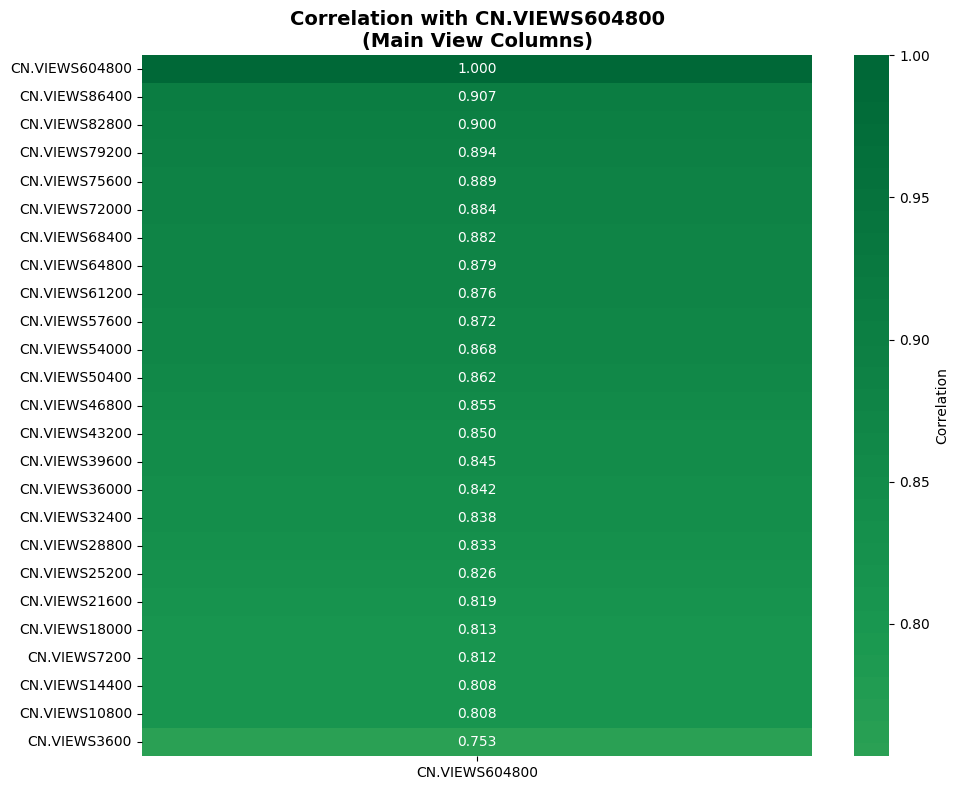

✓ Saved: correlations_target_main.png

Creating 2/3: Top 15 derivative features...


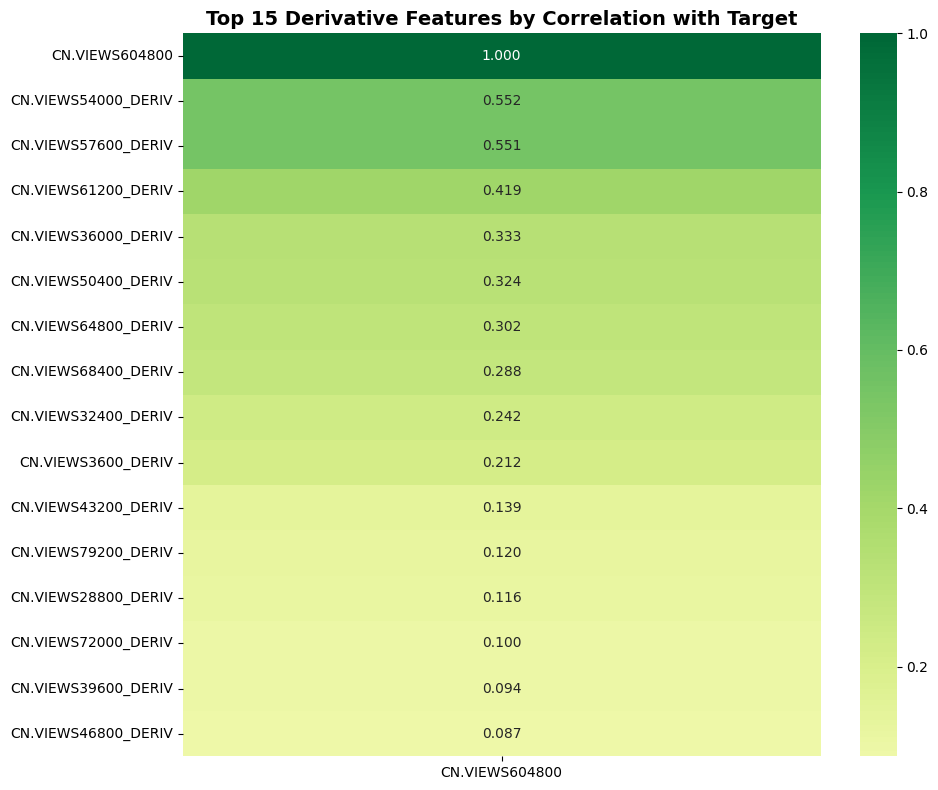

✓ Saved: correlations_top_15_derivatives.png

Creating 3/3: All features sorted by correlation (bar plot)...


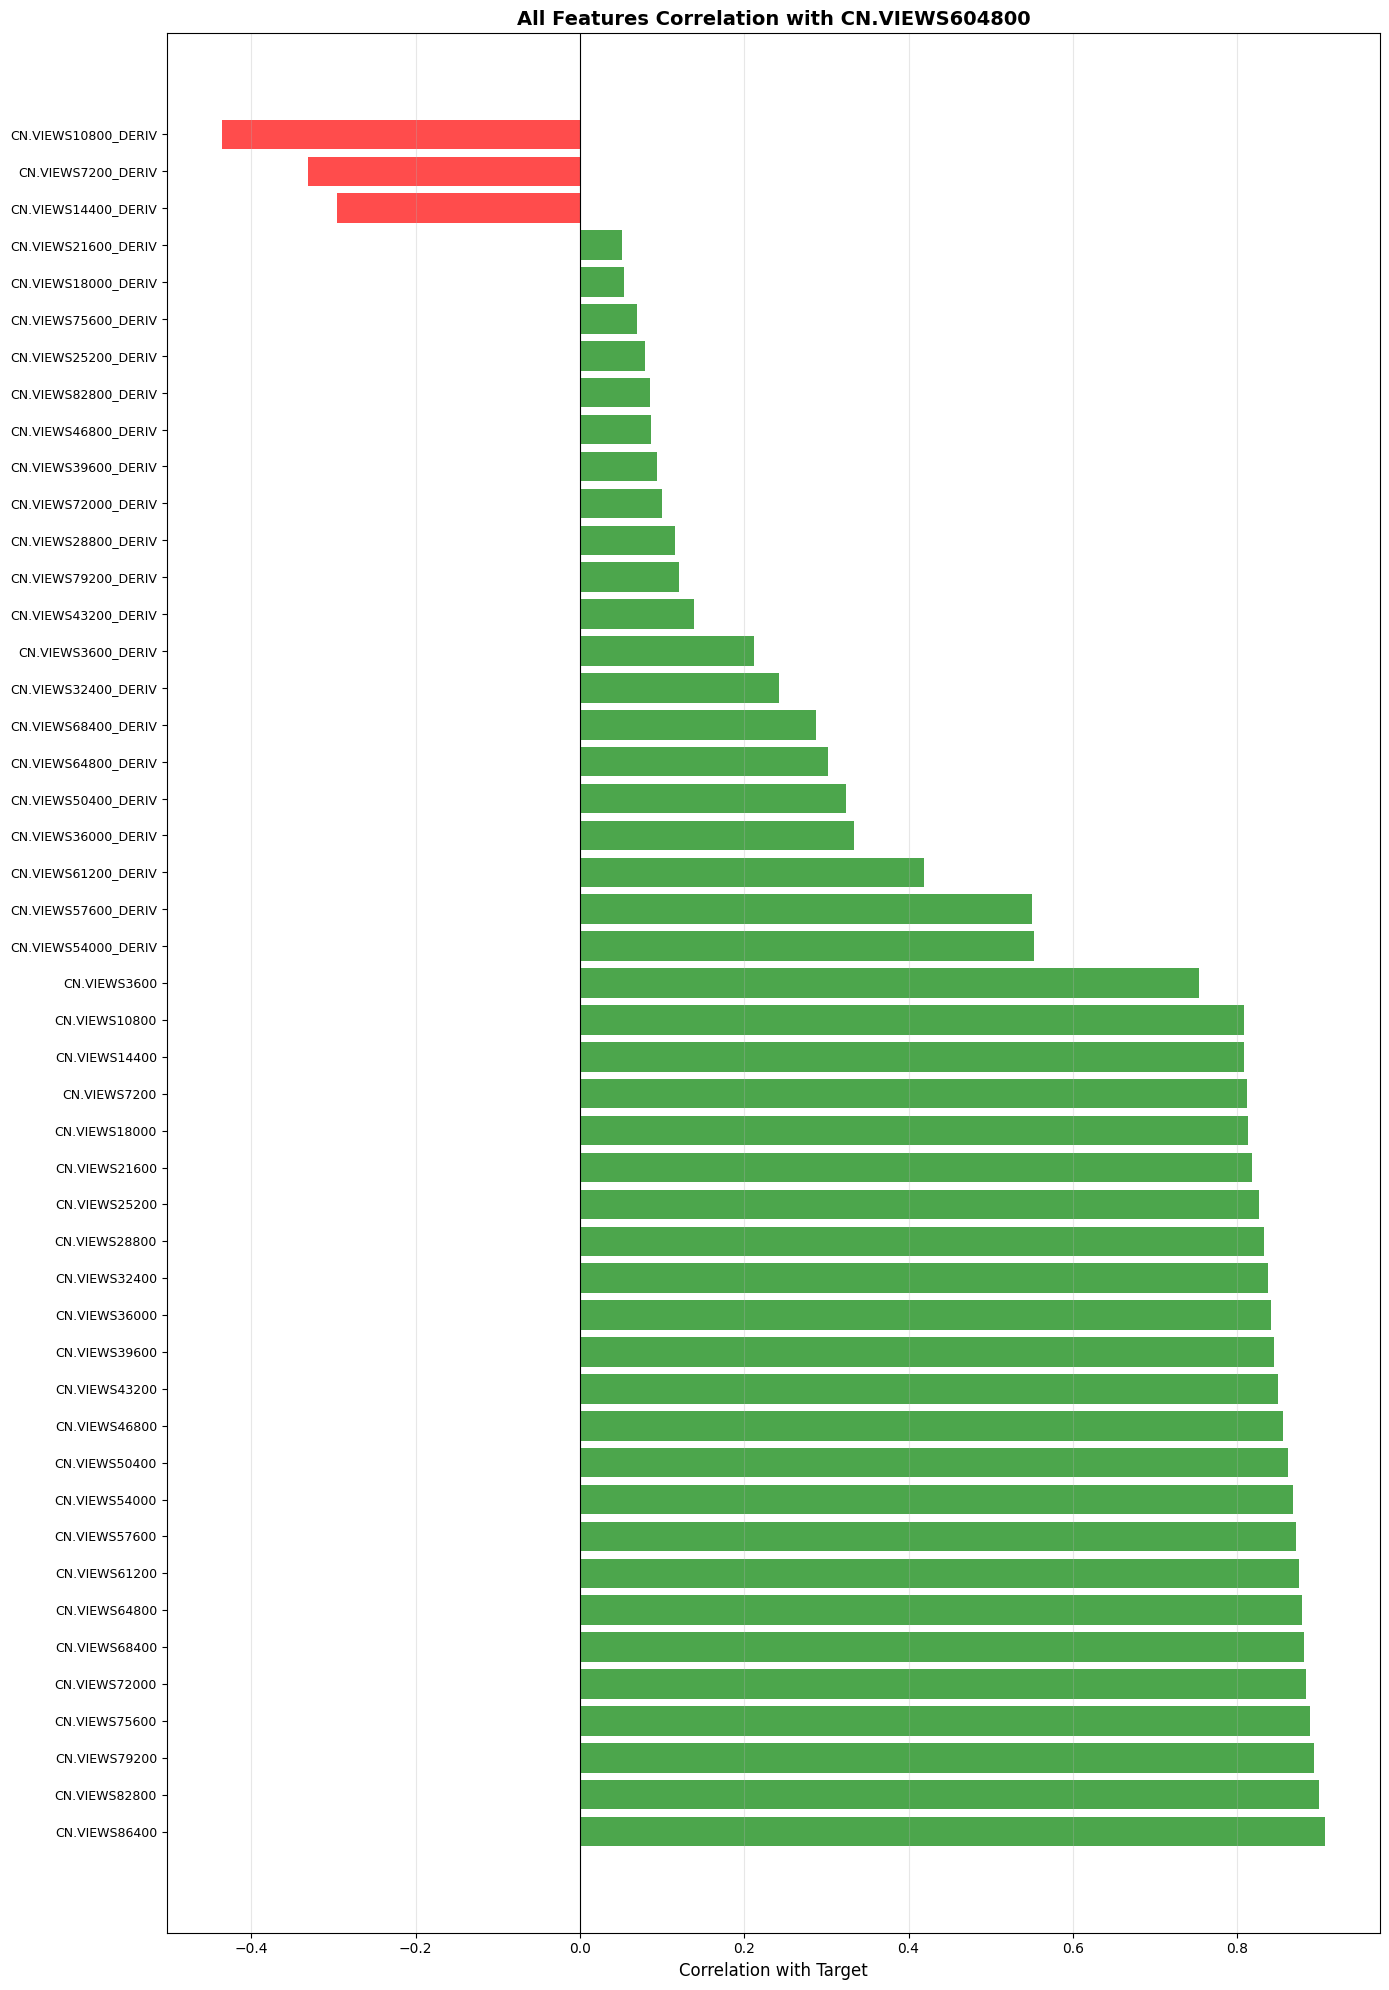

✓ Saved: correlations_all_features_barplot.png

TOP 10 FEATURES BY CORRELATION:
               CN.VIEWS604800
CN.VIEWS86400        0.906868
CN.VIEWS82800        0.900302
CN.VIEWS79200        0.894164
CN.VIEWS75600        0.889310
CN.VIEWS72000        0.884000
CN.VIEWS68400        0.881816
CN.VIEWS64800        0.878857
CN.VIEWS61200        0.875680
CN.VIEWS57600        0.871961
CN.VIEWS54000        0.867829


In [33]:
target_col = "CN.VIEWS604800"

# === График 1: Корреляции target только с основными просмотрами (без производных) ===
print("Creating 1/3: Target correlations with main view columns...")
view_cols_only = [
    c for c in df.columns if "VIEWS" in c and "DERIV" not in c and c != target_col
]
target_corr_main = (
    df[[target_col] + view_cols_only]
    .corr()[[target_col]]
    .sort_values(target_col, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    target_corr_main,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    ax=ax,
    cbar_kws={"label": "Correlation"},
)
ax.set_title(
    f"Correlation with {target_col}\n(Main View Columns)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("correlations_target_main.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: correlations_target_main.png\n")

# === График 2: Топ 15 производных признаков по корреляции ===
print("Creating 2/3: Top 15 derivative features...")
derivative_cols = [c for c in df.columns if "DERIV" in c]
target_corr_deriv = (
    df[[target_col] + derivative_cols]
    .corr()[[target_col]]
    .sort_values(target_col, ascending=False)
)
top_15_deriv = target_corr_deriv[:16]  # 16 включая сам target

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(top_15_deriv, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title(
    "Top 15 Derivative Features by Correlation with Target",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("correlations_top_15_derivatives.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: correlations_top_15_derivatives.png\n")

# === График 3: Bar plot - все признаки отсортированные ===
print("Creating 3/3: All features sorted by correlation (bar plot)...")
all_corr = df.corr()[[target_col]].sort_values(target_col, ascending=False)[
    1:
]  # Без самого target

fig, ax = plt.subplots(figsize=(14, 20))
corr_values = all_corr[target_col].values  # Получаем одномерный массив
colors = ["green" if x > 0 else "red" for x in corr_values]
ax.barh(range(len(all_corr)), corr_values, color=colors, alpha=0.7)
ax.set_yticks(range(len(all_corr)))
ax.set_yticklabels(all_corr.index, fontsize=9)
ax.set_xlabel("Correlation with Target", fontsize=12)
ax.set_title(
    f"All Features Correlation with {target_col}", fontsize=14, fontweight="bold"
)
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("correlations_all_features_barplot.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: correlations_all_features_barplot.png\n")

# === Заключение ===
print("=" * 70)
print("TOP 10 FEATURES BY CORRELATION:")
print("=" * 70)
print(all_corr.head(10))